# Apex Legends Steam Review Sentiment Analysis

## Project Overview
This notebook analyzes player sentiment in Apex Legends Steam reviews.
The objective is to classify reviews into **positive** and **negative** sentiment classes,
then evaluate model performance using standard classification metrics.


## 1) Import Libraries

In [2]:
import re
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from gensim.models import Word2Vec
from nltk.stem import PorterStemmer
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.utils import resample

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

## 2) Load Dataset
Dataset source: scraped from Steam reviews for Apex Legends (App ID `1172470`).
The scraping script is provided in `scrape_apex_reviews.py`.

In [3]:
df = pd.read_csv("review_1172470.csv")
df.head()

,name,language,text,label
0,141696302,english,9/10 Recommended A very movement oriented and...,True
1,143905920,english,Apex Legends: Thrilling Gameplay and Movement...,True
2,142248600,english,"Before I played this, I had a small penis, no...",True
3,142919013,english,- Feel like a clown that wants to win duels in...,True
4,146705243,english,fortnite but from ea - bots are fun to defeat...,True


In [4]:
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
df.info()

Rows: 20,871
Columns: 4
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20871 entries, 0 to 20870
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   name      20871 non-null  int64 
 1   language  20871 non-null  object
 2   text      20871 non-null  object
 3   label     20871 non-null  bool  
dtypes: bool(1), int64(1), object(2)
memory usage: 509.7+ KB


## 3) Data Cleaning and Preparation

In [5]:
working_df = df.copy()

# Keep required columns only
working_df = working_df[["text", "label"]].dropna(subset=["text", "label"])

# Normalize label to integer: positive=True->1, negative=False->0
working_df["label"] = working_df["label"].astype(str).str.lower().map({"true": 1, "false": 0})
working_df = working_df.dropna(subset=["label"])
working_df["label"] = working_df["label"].astype(int)

stemmer = PorterStemmer()
stop_words = set(ENGLISH_STOP_WORDS)

def text_preprocess(text: str) -> str:
    text = str(text)

    # 1) Cleansing: remove URLs, punctuation, and extra spaces
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"[^A-Za-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    # 2) Case folding
    text = text.lower()

    # 3) Tokenizing
    tokens = text.split()

    # 4) Filtering (stopword removal and one-char token removal)
    tokens = [token for token in tokens if token not in stop_words and len(token) > 1]

    # 5) Stemming (Porter Stemmer)
    tokens = [stemmer.stem(token) for token in tokens]

    return " ".join(tokens)

working_df["clean_text"] = working_df["text"].apply(text_preprocess)
working_df = working_df[working_df["clean_text"].str.len() > 0].reset_index(drop=True)

working_df.head()

,text,label,clean_text
0,9/10 Recommended A very movement oriented and...,1,recommended a very movement oriented and dynam...
1,Apex Legends: Thrilling Gameplay and Movement...,1,apex legends thrilling gameplay and movement m...
2,"Before I played this, I had a small penis, no...",1,before i played this i had a small penis no gi...
3,- Feel like a clown that wants to win duels in...,1,feel like a clown that wants to win duels in o...
4,fortnite but from ea - bots are fun to defeat...,1,fortnite but from ea bots are fun to defeat cu...


In [6]:
label_map = {1: "Positive", 0: "Negative"}
working_df["sentiment"] = working_df["label"].map(label_map)
working_df["sentiment"].value_counts()

sentiment
Positive    14478
Negative     5932
Name: count, dtype: int64

## 4) Exploratory Data Analysis

C:\Users\Administrator\AppData\Local\Temp\ipykernel_7328\170917765.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=working_df, x="sentiment", order=["Positive", "Negative"], palette="viridis")


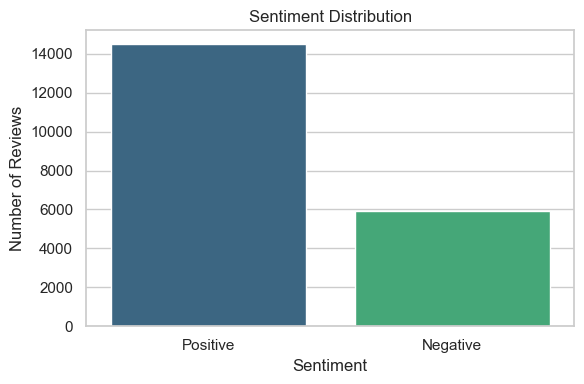

In [7]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=working_df, x="sentiment", order=["Positive", "Negative"], palette="viridis")
ax.set_title("Sentiment Distribution")
ax.set_xlabel("Sentiment")
ax.set_ylabel("Number of Reviews")
plt.tight_layout()
plt.show()

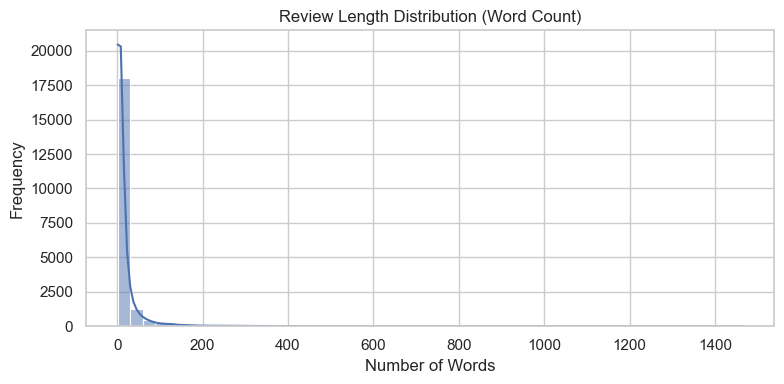

In [8]:
working_df["review_length"] = working_df["clean_text"].str.split().str.len()

plt.figure(figsize=(8, 4))
sns.histplot(data=working_df, x="review_length", bins=50, kde=True)
plt.title("Review Length Distribution (Word Count)")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

## 5) Train/Test Split

In [9]:
X = working_df["clean_text"]
y = working_df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

train_df = pd.DataFrame({"text": X_train, "label": y_train})
majority_df = train_df[train_df["label"] == train_df["label"].mode()[0]]
minority_df = train_df[train_df["label"] != train_df["label"].mode()[0]]

minority_upsampled = resample(
    minority_df,
    replace=True,
    n_samples=len(majority_df),
    random_state=RANDOM_STATE,
)

balanced_train_df = pd.concat([majority_df, minority_upsampled]).sample(frac=1, random_state=RANDOM_STATE)
X_train = balanced_train_df["text"]
y_train = balanced_train_df["label"]

print(f"Train size (balanced): {len(X_train):,}")
print(f"Test size: {len(X_test):,}")
print("Balanced train distribution:")
print(y_train.value_counts())

Train size: 16,328
Test size: 4,082


## 6) Modeling (Word2Vec + Naive Bayes)

In [10]:
# Tokenize text for Word2Vec
X_train_tokens = X_train.apply(lambda text: text.split())
X_test_tokens = X_test.apply(lambda text: text.split())

# Train Word2Vec embeddings on training split only
w2v_model = Word2Vec(
    sentences=X_train_tokens,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4,
    seed=RANDOM_STATE,
)

def sentence_vector(tokens, model):
    vectors = [model.wv[token] for token in tokens if token in model.wv]
    if not vectors:
        return np.zeros(model.vector_size)
    return np.mean(vectors, axis=0)

X_train_vec = np.vstack(X_train_tokens.apply(lambda tokens: sentence_vector(tokens, w2v_model)).values)
X_test_vec = np.vstack(X_test_tokens.apply(lambda tokens: sentence_vector(tokens, w2v_model)).values)

# MultinomialNB requires non-negative features
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train_vec)
X_test_scaled = scaler.transform(X_test_vec)

model = MultinomialNB()
model.fit(X_train_scaled, y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


## 7) Evaluation

In [11]:
y_pred = model.predict(X_test_scaled)
acc = accuracy_score(y_test, y_pred)

print(f"Accuracy: {acc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Negative", "Positive"], zero_division=0))

Accuracy: 0.7095

Classification Report:
              precision    recall  f1-score   support

    Negative       0.00      0.00      0.00      1186
    Positive       0.71      1.00      0.83      2896

    accuracy                           0.71      4082
   macro avg       0.35      0.50      0.42      4082
weighted avg       0.50      0.71      0.59      4082



c:\ProgramData\anaconda3\envs\data-analyst\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\ProgramData\anaconda3\envs\data-analyst\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\ProgramData\anaconda3\envs\data-analyst\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize

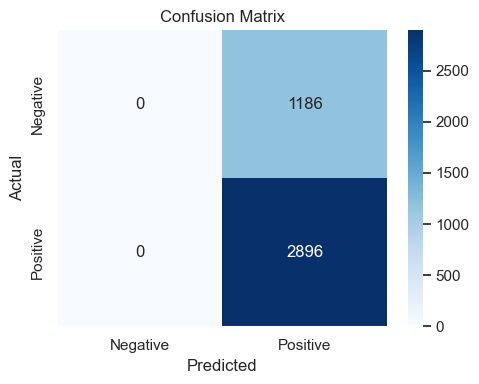

In [12]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"],
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

## 8) Sample Predictions

In [13]:
sample_reviews = pd.DataFrame({"review": X_test.sample(5, random_state=RANDOM_STATE).values})
sample_tokens = sample_reviews["review"].apply(lambda text: text.split())
sample_vectors = np.vstack(sample_tokens.apply(lambda tokens: sentence_vector(tokens, w2v_model)).values)
sample_scaled = scaler.transform(sample_vectors)
sample_reviews["prediction"] = pd.Series(model.predict(sample_scaled)).map(label_map)
sample_reviews

,review,prediction
0,overall pretty good game definitely much bette...,Positive
1,this game gave me caniceer,Positive
2,i recommend this game,Positive
3,the promo add for the season says worlds edge ...,Positive
4,titanfall got gutted for this mess of a game,Positive


## 9) Key Takeaways
- This project demonstrates an end-to-end NLP workflow for sentiment classification.
- The final model uses Word2Vec embeddings with Multinomial Naive Bayes.
- The dataset was obtained via Steam review scraping (see `scrape_apex_reviews.py`).
- This notebook can be extended with hyperparameter tuning and model comparison.